# Neural Networks from Scratch

**Applied ML in Production · Bonus 1 of 4**

---

The ten core sessions deliberately stayed with models you can explain to a credit
committee. This bonus series covers the other half of modern machine learning —
neural networks, convolutions, recurrence, and attention — and it starts here,
with the smallest possible question: **what is a neuron, and why would you stack
them?**

We build a network twice. First in twenty lines of NumPy, deriving the gradients
by hand, so that nothing is magic. Then in PyTorch, so you can see what the
library is doing on your behalf.

Then we do something the tutorials skip: we point the network at session 2's loan
data and compare it honestly with logistic regression.

## How to work through this

Type the code. The NumPy network is the most important twenty lines in this
series — everything later is that idea with more structure.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- Describe a neuron as a weighted sum, a bias, and an activation function.
- Explain why logistic regression *is* a single-neuron network.
- Say what problem hidden layers solve, and demonstrate it on XOR.
- Implement forward propagation and **backpropagation** by hand in NumPy.
- Use PyTorch tensors, autograd, `nn.Module`, and a standard training loop.
- Recognise overfitting from training and validation curves.
- Judge when a neural network is the right choice for a tabular problem — and
  when it is not.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
torch.manual_seed(0)
np.random.seed(0)

print("torch", torch.__version__)
print("everything here runs on the CPU in seconds — no GPU required")

torch 2.13.0
everything here runs on the CPU in seconds — no GPU required


---

## 1. A neuron

A neuron does three things:

1. Multiply each input by a weight and add them up.
2. Add a bias.
3. Pass the result through an **activation function**.

$$ a = f(w_1x_1 + w_2x_2 + \dots + w_nx_n + b) $$

If the activation is the sigmoid, that is *exactly* logistic regression. You have
been using a one-neuron neural network since session 4.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


weights = np.array([0.8, -1.2])      # what the model learned
bias = 0.1
inputs = np.array([1.5, 0.4])        # one application, two features

z = inputs @ weights + bias
print(f"weighted sum + bias: {z:.3f}")
print(f"after sigmoid:       {sigmoid(z):.3f}   <- a probability")

weighted sum + bias: 0.820
after sigmoid:       0.694   <- a probability


### Activation functions

Without an activation, stacking layers is pointless: a chain of linear maps is
just another linear map. The activation is what makes depth mean something.

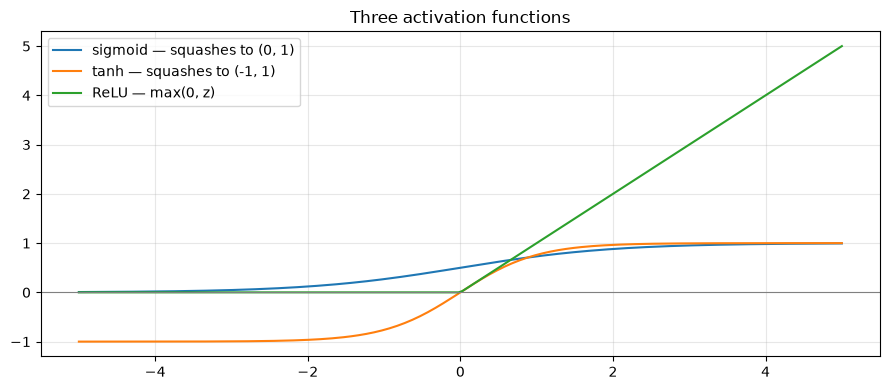

In [3]:
z = np.linspace(-5, 5, 200)

plt.plot(z, sigmoid(z), label="sigmoid — squashes to (0, 1)")
plt.plot(z, np.tanh(z), label="tanh — squashes to (-1, 1)")
plt.plot(z, np.maximum(0, z), label="ReLU — max(0, z)")
plt.axhline(0, color="grey", linewidth=0.8)
plt.legend()
plt.title("Three activation functions")
plt.tight_layout()
plt.show()

| Activation | Range | Where you meet it |
|------------|-------|-------------------|
| **Sigmoid** | 0 to 1 | Output layer for binary classification |
| **Tanh** | −1 to 1 | Hidden layers in older networks, and inside LSTMs |
| **ReLU** | 0 to ∞ | The default for hidden layers since about 2012 |

ReLU won for an unglamorous reason: its gradient is exactly 1 for positive inputs,
so gradients do not shrink as they pass back through many layers. Sigmoid's
gradient is at most 0.25, so ten layers of it multiply to nearly nothing — the
**vanishing gradient** problem, which bonus 3 revisits when we reach RNNs.

---

## 2. Why depth: the XOR problem

Here is the smallest problem a single neuron cannot solve. Output 1 when exactly
one input is 1.

| x₁ | x₂ | y |
|----|----|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

No straight line separates the 1s from the 0s. Logistic regression draws straight
lines, so it cannot do better than guessing.

In [4]:
from sklearn.linear_model import LogisticRegression

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [0]], dtype=float)

single_neuron = LogisticRegression().fit(X, y.ravel())
print("logistic regression accuracy on XOR:", single_neuron.score(X, y.ravel()))
print("predictions:", single_neuron.predict(X))

logistic regression accuracy on XOR: 0.5
predictions: [0. 0. 0. 0.]


50% — a coin flip. This is the same limitation as session 3's interaction
example: a linear model cannot express "one **or** the other, but not both"
unless you hand it the right feature.

A hidden layer builds that feature for itself.

---

## 3. Backpropagation, by hand

A network learns by repeating four steps:

1. **Forward pass** — push inputs through the layers to a prediction.
2. **Loss** — measure how wrong the prediction is.
3. **Backward pass** — work out how much each weight contributed to the error.
4. **Update** — nudge every weight against its gradient.

Step 3 is backpropagation, and it is the chain rule applied layer by layer. Here
it is in full, for a network with one hidden layer of eight tanh units.

In [5]:
rng = np.random.default_rng(0)
HIDDEN = 8
LEARNING_RATE = 1.0

W1 = rng.normal(0, 1, (2, HIDDEN))      # input -> hidden
b1 = np.zeros((1, HIDDEN))
W2 = rng.normal(0, 1, (HIDDEN, 1))      # hidden -> output
b2 = np.zeros((1, 1))

history = []
for epoch in range(5001):
    # 1. forward
    hidden = np.tanh(X @ W1 + b1)
    output = sigmoid(hidden @ W2 + b2)

    # 2. loss (binary cross-entropy)
    loss = -np.mean(y * np.log(output + 1e-9) + (1 - y) * np.log(1 - output + 1e-9))

    # 3. backward — the chain rule, one layer at a time
    d_output = (output - y) / len(X)              # dLoss/dz for sigmoid + cross-entropy
    dW2 = hidden.T @ d_output
    db2 = d_output.sum(axis=0, keepdims=True)

    d_hidden = (d_output @ W2.T) * (1 - hidden ** 2)   # tanh'(z) = 1 - tanh(z)^2
    dW1 = X.T @ d_hidden
    db1 = d_hidden.sum(axis=0, keepdims=True)

    # 4. update
    W1 -= LEARNING_RATE * dW1
    b1 -= LEARNING_RATE * db1
    W2 -= LEARNING_RATE * dW2
    b2 -= LEARNING_RATE * db2

    history.append(loss)
    if epoch % 1000 == 0:
        print(f"epoch {epoch:>5}   loss {loss:.4f}")

print("\nfinal predictions:", output.ravel().round(3))
print("targets:          ", y.ravel())

epoch     0   loss 0.7414
epoch  1000   loss 0.0013
epoch  2000   loss 0.0006
epoch  3000   loss 0.0004
epoch  4000   loss 0.0003
epoch  5000   loss 0.0002

final predictions: [0. 1. 1. 0.]
targets:           [0. 1. 1. 0.]


It learned XOR. Twenty lines, no framework, and the only mathematics is the chain
rule.

Two lines deserve a second look. `d_output = (output - y) / len(X)` is the
gradient of cross-entropy with respect to the pre-sigmoid value — the sigmoid
derivative and the log cancel, which is why this pairing is standard.
`(1 - hidden ** 2)` is the tanh derivative, and it is where the **vanishing
gradient** lives: when a unit saturates near ±1, that factor approaches zero and
the layers behind it stop learning.

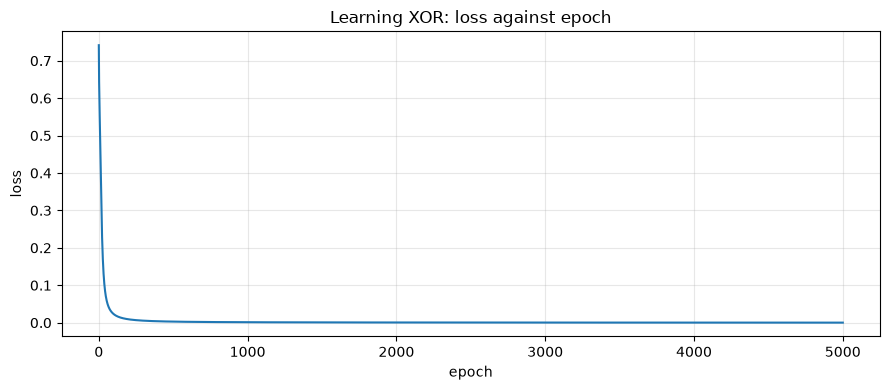

In [6]:
plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Learning XOR: loss against epoch")
plt.tight_layout()
plt.show()

Notice the shape: almost everything happens in the first few hundred epochs — the
loss is already down to 0.02 by epoch 100 — and the remaining 4,900 epochs polish
a solution that was essentially found early. That is typical, and it is why the
sensible stopping rule is "when validation stops improving" rather than a fixed
epoch count.

The shape is also fragile. With a narrower hidden layer the curve can flatten
early at a much worse loss and stay there, which is the next note.

> **Try this later.** Set `HIDDEN = 4` and keep the seed at 0. The network stalls
> at a loss around 0.35 and learns only half the truth table. Same architecture
> class, same data, different starting weights — that is how much initialisation
> matters, and why `random_state` is not optional in this corner of the field.

---

## 4. The same thing in PyTorch

PyTorch does two things for you: it records the operations you perform so it can
compute gradients automatically (**autograd**), and it gives you layers,
optimisers and loss functions off the shelf.

Start with autograd on a single number, so the magic is small.

In [7]:
x = torch.tensor(2.0, requires_grad=True)
z = 3 * x ** 2 + 1

z.backward()                 # walk the graph backwards, filling in gradients

print(f"z = 3x² + 1 at x = 2 gives z = {z.item():.1f}")
print(f"dz/dx = 6x = {x.grad.item():.1f}   (computed, not derived by us)")

z = 3x² + 1 at x = 2 gives z = 13.0
dz/dx = 6x = 12.0   (computed, not derived by us)


That is the whole trick. Every operation on a tensor with `requires_grad=True` is
recorded; `backward()` replays the chain rule through the recording.

Now the XOR network again — same architecture, none of the derivatives.

In [8]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

model = nn.Sequential(
    nn.Linear(2, 8),      # input -> hidden
    nn.Tanh(),
    nn.Linear(8, 1),      # hidden -> output
)

loss_function = nn.BCEWithLogitsLoss()               # sigmoid + cross-entropy, fused
optimiser = torch.optim.SGD(model.parameters(), lr=1.0)

for epoch in range(5001):
    optimiser.zero_grad()                 # clear last step's gradients
    logits = model(X_tensor)              # forward
    loss = loss_function(logits, y_tensor)
    loss.backward()                       # backward — autograd does section 3
    optimiser.step()                      # update

    if epoch % 1000 == 0:
        print(f"epoch {epoch:>5}   loss {loss.item():.4f}")

print("\npredictions:", torch.sigmoid(model(X_tensor)).detach().numpy().ravel().round(3))

epoch     0   loss 0.7012
epoch  1000   loss 0.0013
epoch  2000   loss 0.0006


epoch  3000   loss 0.0004
epoch  4000   loss 0.0003
epoch  5000   loss 0.0002

predictions: [0. 1. 1. 0.]


Four lines inside the loop, and they are the same four lines for every neural
network you will ever train — including the transformer in bonus 4.

| Line | What it does | The NumPy equivalent |
|------|--------------|----------------------|
| `optimiser.zero_grad()` | Clear gradients from the last step | (we overwrote them) |
| `model(X)` | Forward pass | `np.tanh(X @ W1 + b1)` etc. |
| `loss.backward()` | Compute every gradient | the whole of step 3 |
| `optimiser.step()` | Update the weights | `W1 -= lr * dW1` etc. |

**Forgetting `zero_grad()` is the classic PyTorch bug.** Gradients accumulate by
default, so without it your updates are the sum of every batch so far and training
quietly diverges.

### `nn.Module`: the version you will actually write

`nn.Sequential` is fine for a straight chain. Anything with branches, skips or
custom logic wants a class.

In [9]:
class SmallNet(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        self.hidden = nn.Linear(n_features, hidden)
        self.output = nn.Linear(hidden, 1)
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.output(self.activation(self.hidden(x)))


net = SmallNet(n_features=2)
print(net)
print(f"\nparameters: {sum(p.numel() for p in net.parameters()):,}")

SmallNet(
  (hidden): Linear(in_features=2, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (activation): ReLU()
)

parameters: 129


---

## 5. A neural network on the loan problem

Now the question this module cares about. Sessions 4 and 6 established that
logistic regression reaches ROC-AUC 0.782 on the loan data, and that gradient
boosting could not beat it by more than noise.

Can a neural network?

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def find_repository_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "data").is_dir():
            return folder
    raise FileNotFoundError("could not find the repository root")


ROOT = find_repository_root()
loans = pd.read_csv(ROOT / "data" / "loan_default.csv")

NUMERIC = ["loan_amount", "tenure_months", "interest_rate", "previous_loans",
           "days_past_due_history", "annual_income", "credit_score"]
CATEGORICAL = ["sector", "employment_type", "has_collateral"]

preparation = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC),
    ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                              ("encode", OneHotEncoder(handle_unknown="ignore", drop="first"))]),
     CATEGORICAL),
])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    loans[NUMERIC + CATEGORICAL], loans["defaulted"],
    test_size=0.25, stratify=loans["defaulted"], random_state=42,
)

X_train = np.asarray(preparation.fit_transform(X_train_raw), dtype=np.float32)
X_test = np.asarray(preparation.transform(X_test_raw), dtype=np.float32)

print(f"{X_train.shape[0]:,} training rows, {X_train.shape[1]} features after preprocessing")
print("scaling matters more for neural networks than for anything else —")
print("unscaled inputs make the gradients wildly different sizes per feature")

9,000 training rows, 16 features after preprocessing
scaling matters more for neural networks than for anything else —
unscaled inputs make the gradients wildly different sizes per feature


In [11]:
from torch.utils.data import DataLoader, TensorDataset

train_data = TensorDataset(torch.tensor(X_train),
                           torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1))
loader = DataLoader(train_data, batch_size=256, shuffle=True)

net = SmallNet(n_features=X_train.shape[1], hidden=32)
optimiser = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_function = nn.BCEWithLogitsLoss()

for epoch in range(60):
    net.train()
    for batch_X, batch_y in loader:
        optimiser.zero_grad()
        loss = loss_function(net(batch_X), batch_y)
        loss.backward()
        optimiser.step()

net.eval()
with torch.no_grad():
    probabilities = torch.sigmoid(net(torch.tensor(X_test))).numpy().ravel()

logistic = LogisticRegression(max_iter=1000).fit(X_train, y_train)
logistic_probabilities = logistic.predict_proba(X_test)[:, 1]

print(f"neural network      AUC {roc_auc_score(y_test, probabilities):.4f}   "
      f"AP {average_precision_score(y_test, probabilities):.4f}")
print(f"logistic regression AUC {roc_auc_score(y_test, logistic_probabilities):.4f}   "
      f"AP {average_precision_score(y_test, logistic_probabilities):.4f}")

neural network      AUC 0.7795   AP 0.3848
logistic regression AUC 0.7822   AP 0.3817


A dead heat — and session 6 taught us to read a difference that small as noise,
because the cross-validation folds varied by ±0.03.

This is the normal result on small, tidy tabular data, and it is worth saying
plainly: **neural networks are not a general upgrade.** They win where the
structure of the data is something a human would have to hand-engineer features
for — pixels, waveforms, characters, sequences — and they lose where a linear
model already fits, because they pay for flexibility with data hunger,
opacity, and tuning.

| Neural networks win | Classical models win |
|---------------------|----------------------|
| Images, audio, text, video | Tabular data with meaningful columns |
| Hundreds of thousands of examples | Thousands of examples |
| Raw inputs, no obvious features | Features a domain expert can name |
| Accuracy dominates explainability | Decisions must be defended |

Our charter demanded explainable declines. That alone would have settled it,
before a single epoch.

### Bigger is not better

deeper network AUC 0.7757


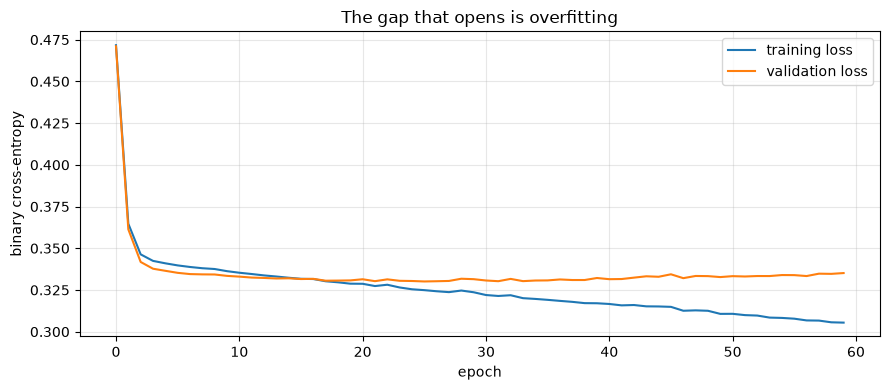

In [12]:
deeper = nn.Sequential(
    nn.Linear(X_train.shape[1], 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
optimiser = torch.optim.Adam(deeper.parameters(), lr=1e-3)

train_curve, test_curve = [], []
X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

for epoch in range(60):
    deeper.train()
    for batch_X, batch_y in loader:
        optimiser.zero_grad()
        loss = loss_function(deeper(batch_X), batch_y)
        loss.backward()
        optimiser.step()

    deeper.eval()
    with torch.no_grad():
        train_curve.append(loss_function(deeper(torch.tensor(X_train)),
                                         torch.tensor(y_train.to_numpy(), dtype=torch.float32).unsqueeze(1)).item())
        test_curve.append(loss_function(deeper(X_test_tensor), y_test_tensor).item())

with torch.no_grad():
    deep_probabilities = torch.sigmoid(deeper(X_test_tensor)).numpy().ravel()
print(f"deeper network AUC {roc_auc_score(y_test, deep_probabilities):.4f}")

plt.plot(train_curve, label="training loss")
plt.plot(test_curve, label="validation loss")
plt.xlabel("epoch")
plt.ylabel("binary cross-entropy")
plt.title("The gap that opens is overfitting")
plt.legend()
plt.tight_layout()
plt.show()

The training loss keeps falling and the validation loss stops improving, then
turns upward. That divergence is session 4's train–test gap, watched live.

The standard defences, in the order you should reach for them:

| Defence | What it does |
|---------|--------------|
| **Early stopping** | Stop at the validation minimum — free, and always worth doing |
| **More data** | The only fix that adds information |
| **Weight decay** (`weight_decay=` in the optimiser) | L2 regularisation, exactly as in ridge |
| **Dropout** (`nn.Dropout(0.2)`) | Randomly zeroes units during training, forcing redundancy |
| **A smaller network** | The defence people skip, and often the right one |

---

## 6. The training loop, annotated once

Every notebook in this bonus series uses this loop. Learn it here.

```python
for epoch in range(epochs):
    model.train()                          # enable dropout / batch-norm training behaviour
    for batch_X, batch_y in loader:        # mini-batches, reshuffled each epoch
        optimiser.zero_grad()              # clear old gradients
        loss = loss_function(model(batch_X), batch_y)
        loss.backward()                    # autograd fills every .grad
        optimiser.step()                   # weights move against the gradient

    model.eval()                           # disable dropout for evaluation
    with torch.no_grad():                  # no gradient bookkeeping — faster, less memory
        validate(model)
```

| Choice | Typical starting point | Why |
|--------|------------------------|-----|
| **Optimiser** | `Adam(lr=1e-3)` | Adapts per-parameter step sizes; forgiving |
| **Batch size** | 32–256 | Bigger is faster per epoch, noisier gradients are sometimes better |
| **Learning rate** | 1e-3, then tune by factors of 10 | The single most important hyperparameter |
| **Epochs** | As many as validation keeps improving | Combine with early stopping |
| **Loss** | `BCEWithLogitsLoss` (binary), `CrossEntropyLoss` (multi-class), `MSELoss` (regression) | Must match the output layer |

Two rules that save hours of confusion.

**Match the loss to the final layer.** `BCEWithLogitsLoss` and `CrossEntropyLoss`
apply the sigmoid or softmax internally, so your model must output **raw logits**.
Applying a sigmoid yourself and then using `BCEWithLogitsLoss` trains a
sigmoid-of-a-sigmoid, which learns badly and silently.

**Scale your inputs.** Neural networks are far more sensitive to feature scale
than trees. Session 7's `ColumnTransformer` earns its place here too.

---

## Your turn

**1. Break XOR.** Set `HIDDEN = 4` in section 3 and re-run. What final loss do you
get, and which rows does the network get wrong? Now change the seed. How many
seeds out of five succeed?

**2. Activation matters.** Replace `np.tanh` in the NumPy network with the ReLU
`np.maximum(0, z)` — remembering that its derivative is `(z > 0)`. Does it learn
faster, slower, or not at all?

**3. Learning rate sweep.** Train the loan network with learning rates 1e-1, 1e-2,
1e-3 and 1e-4 for 30 epochs each, and plot the loss curves together. Which
diverges, which crawls?

**4. Add regularisation.** Give the deeper network `weight_decay=1e-3` and a
`nn.Dropout(0.3)` layer. Does the validation curve stop turning upward, and does
the test AUC improve?

**5. Early stopping.** Modify the training loop to keep the weights from the epoch
with the lowest validation loss (`copy.deepcopy(model.state_dict())`). Report the
AUC of the saved model against the final one.

**6. The honest comparison.** Cross-validate the neural network properly — five
folds, retraining each time — and report mean ± standard deviation against
logistic regression's 0.363 ± 0.032 average precision from session 6. Is the
difference larger than the fold spread?

---

## If you remember nothing else

**A neuron is a weighted sum, a bias, and an activation.** Logistic regression is
one neuron with a sigmoid.

**Depth buys you non-linearity.** A single layer cannot solve XOR; one hidden
layer can. Without an activation function, depth buys nothing at all.

**Backpropagation is the chain rule, applied layer by layer.** You wrote it in
twenty lines; PyTorch just automates the bookkeeping.

**Four lines are the whole training loop.** `zero_grad`, forward, `backward`,
`step` — and forgetting the first is the classic bug.

**Neural networks are not a general upgrade.** On the loan data a network matched
logistic regression and a deeper one was worse. They earn their keep on pixels,
audio, text and sequences — which is exactly what the next three notebooks are.

**Watch the two curves.** Training loss falling while validation loss rises is
overfitting, live.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Neuron / unit** | Weighted sum of inputs plus bias, passed through an activation |
| **Activation function** | The non-linearity — sigmoid, tanh, ReLU |
| **Hidden layer** | Any layer between input and output |
| **Forward pass** | Computing the prediction from the inputs |
| **Loss function** | The number training minimises |
| **Backpropagation** | Computing gradients by applying the chain rule backwards |
| **Gradient descent** | Moving weights against their gradients |
| **Epoch** | One pass over the whole training set |
| **Mini-batch** | A subset of rows used for one update |
| **Autograd** | PyTorch's automatic differentiation |
| **Logits** | Raw model outputs before sigmoid or softmax |
| **Vanishing gradient** | Gradients shrinking toward zero through many layers |
| **Dropout** | Randomly zeroing units during training, as regularisation |
| **Weight decay** | L2 regularisation applied by the optimiser |

## Further reading

- Michael Nielsen, *Neural Networks and Deep Learning*, chapters 1–2 — free, and
  the clearest derivation of backpropagation in existence.
- Andrej Karpathy, *The spelled-out intro to neural networks* (micrograd) — builds
  autograd from nothing in a couple of hours.
- PyTorch documentation, *Learn the Basics* — tensors through training loop.
- Goodfellow, Bengio and Courville, *Deep Learning*, chapter 6 — the reference
  treatment of feed-forward networks.

---

**Next:** *Convolutional Neural Networks* — why a fully connected network is the
wrong shape for an image, and what convolution does instead.